# Stage 1 (phi-only) Monthly Occurrence-Probability ($\pi_t$) Seasonality

## Objective

For the Stage 1 **phi-only** winner at each of the six completed locations
(Belo Horizonte, Cruzeiro do Sul, Darwin Airport, Garanhuns, Manaus,
Salvador) -- the baseline GAS specification with a single time-varying
parameter ($\phi_t$; $\xi$ and the AR-logistic occurrence dynamics are
static, per `docs/MODELS.md` Sec 27) -- this notebook builds **two mosaic
figures**, each a fixed 3-row x 2-column grid with one panel per location:

1. **Average $\pi_t$ by calendar month** -- a bar chart of the model's
   in-sample average rain-occurrence probability for each of the 12
   calendar months.
2. **$\pi_t$ vs. empirical wet-day fraction by calendar month** -- the
   same monthly average $\pi_t$ (blue), plotted alongside the empirical
   fraction of wet days observed in that calendar month during training
   (red), as adjacent bars so the two are directly comparable.

The second figure answers the calibration question the first cannot on
its own: does the model's fitted occurrence probability actually track
the empirical seasonal rainfall pattern, or does it systematically over-
or under-estimate occurrence in some months?

Everything here is computed from saved artifacts only -- **no model is
re-estimated** (`docs/EXECUTION.md` Sec 22: "Reports should never call
optimization"). All diagnostics are **in-sample (IS)**, computed over the
training period (`docs/REPORTING.md` Sec 11).

Outputs are written to `reports/multi_location/pi_seasonality/`.


## Mathematical Background

### Occurrence dynamics (Stage 1, phi-only)

The zero-augmented model's rain/no-rain indicator has probability

$$
\pi_t = \sigma(\eta_t), \qquad \sigma(x) = \frac{1}{1+e^{-x}},
$$

where $\eta_t$ follows the AR-logistic occurrence recursion (`docs/MODELS.md`
Sec 3):

$$
\eta_t = \omega_0 + \rho\, \eta_{t-1} + \sum_{l \in \{1,365,366\}} \omega_{y,l}\, \mathbb{1}(y_{t-l} > 0).
$$

This recursion, and the parameters $\omega_0$, $\rho$, $\omega_{y,1}$,
$\omega_{y,365}$, $\omega_{y,366}$, are shared by every Stage 1-4 model at
a location (they are not re-estimated per stage) -- but $\pi_t$ itself
still varies over time because it depends on the lagged rain indicators
$\mathbb{1}(y_{t-l}>0)$. "Stage 1 phi-only" is chosen here (rather than,
say, the phi+xi branch) simply because the question this notebook asks --
does the occurrence sub-model reproduce the seasonal cycle in rain
frequency? -- does not depend on how many GAS time-varying parameters the
*magnitude* sub-model has; the phi-only branch is picked as the
"one time-varying parameter" baseline per the user's request.

### Monthly aggregation

Let $\{t : \text{eff\_start} \le t < T\}$ be the in-sample window after the
model's own GAS warm-up (`models/za_gas_model.py`'s `max_lag`, 3 days for
a short-lag Stage 1 winner). For each calendar month $m \in \{1, ..., 12\}$,

$$
\bar\pi_m = \frac{1}{|\mathcal{T}_m|}\sum_{t \in \mathcal{T}_m} \pi_t,
\qquad
\widehat{w}_m = \frac{1}{|\mathcal{T}_m|}\sum_{t \in \mathcal{T}_m} \mathbb{1}(y_t > 0),
$$

where $\mathcal{T}_m = \{t : \text{month}(t) = m\}$ within the effective
window. $\bar\pi_m$ is the model's average predicted occurrence
probability for month $m$; $\widehat w_m$ is the empirical wet-day
fraction for month $m$. See `diagnostics/pi_monthly.py` for the
implementation.


In [1]:
# =============================================================================
# Imports and project-root path setup
# =============================================================================
# This notebook ORCHESTRATES only -- per docs/EXECUTION.md Sec 23
# ("Notebooks should orchestrate experiments ... They should not contain
# model implementations"), every non-trivial computation (stage-winner
# resolution, model reconstruction, in-sample pi_t computation, monthly
# aggregation, mosaic figure construction) lives in reusable modules:
#     diagnostics/multilocation_mosaics.py  -- data loading, "which model wins"
#     diagnostics/pi_monthly.py             -- monthly pi_t / wet-day aggregation
#     diagnostics/plots.py                  -- what the mosaics look like
# This notebook just calls them in the right order and saves the results.

from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless rendering -- figures are displayed below
                        # via explicit fig.savefig() + IPython Image, not
                        # matplotlib's interactive/inline backend, so this
                        # notebook renders identically whether run inside
                        # Jupyter or from the command line (nbconvert).
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Project root = the directory this notebook lives in.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from diagnostics.multilocation_mosaics import LOCATIONS, load_all_location_data
from diagnostics.pi_monthly import compute_monthly_pi_and_occurrence, MONTH_LABELS
from diagnostics.plots import monthly_pi_mosaic, monthly_pi_occurrence_mosaic
from data.station_loader import STATION_REGISTRY, mosaic_name

print("Locations:", LOCATIONS)
print("Months:   ", MONTH_LABELS)

Locations: ['BELO HORIZONTE', 'CRUZEIRO DO SUL (ACRE)', 'DARWIN AIRPORT', 'GARANHUNS (PERNAMBUCO)', 'MANAUS', 'SALVADOR']
Months:    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


In [2]:
# =============================================================================
# Configuration
# =============================================================================
# Column order for both mosaics -- location *display* names, in the same
# order as diagnostics/multilocation_mosaics.py's LOCATIONS (and therefore
# the same order used by the main multi-location report and the Stage 1-4
# diagnostic mosaics), filled into the fixed 3x2 grid row-major.
LOCATION_DISPLAY_NAMES = [STATION_REGISTRY[s]["display"] for s in LOCATIONS]

# Per-location panel-title overrides, keyed by the *display* name (i.e.
# the same strings as LOCATION_DISPLAY_NAMES) so nothing about how
# figures are looked up needs to change:
#   LOCATION_NAMES     -- text actually drawn as the panel title. Only
#                          Darwin Airport differs from its own "display"
#                          name (data/station_loader.py's mosaic_name());
#                          every other location's title is unchanged.
#   LOCATION_COUNTRIES -- "(Country)" subtitle drawn under the name
#                          (diagnostics/plots.py's _panel_title), from the
#                          new "country" field in STATION_REGISTRY.
LOCATION_NAMES     = {STATION_REGISTRY[s]["display"]: mosaic_name(s) for s in LOCATIONS}
LOCATION_COUNTRIES = {STATION_REGISTRY[s]["display"]: f"({STATION_REGISTRY[s]['country']})" for s in LOCATIONS}

# Output locations. "reports/multi_location" already holds the main report
# (report.tex/.pdf) and the Stage 1-4 diagnostic mosaics
# (reports/multi_location/mosaics/); this notebook's outputs live in their
# own clearly separated subfolder so nothing here ever collides with or
# overwrites either of those.
REPORTS_DIR = ROOT / "reports" / "multi_location"
OUT_DIR     = REPORTS_DIR / "pi_seasonality"
TABLES_DIR  = OUT_DIR / "tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DPI = 150  # matches generate_report_extended.py's per-model figure resolution

print("Outputs will be written to:", OUT_DIR)
print("Location panel titles:", LOCATION_NAMES)
print("Location countries:   ", LOCATION_COUNTRIES)

Outputs will be written to: C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\reports\multi_location\pi_seasonality
Location panel titles: {'Belo Horizonte': 'Belo Horizonte', 'Cruzeiro do Sul': 'Cruzeiro do Sul', 'Darwin Airport': 'Darwin', 'Garanhuns': 'Garanhuns', 'Manaus': 'Manaus', 'Salvador': 'Salvador'}
Location countries:    {'Belo Horizonte': '(Brazil)', 'Cruzeiro do Sul': '(Brazil)', 'Darwin Airport': '(Australia)', 'Garanhuns': '(Brazil)', 'Manaus': '(Brazil)', 'Salvador': '(Brazil)'}


## Figure design settings -- EDIT HERE for font size / readability

**This is the one cell to change if the text in the mosaics looks too
small (or too big) once placed in the LaTeX dissertation.** No other cell
in this notebook needs to change for that.

Same print-size calibration used by `multilocation_diagnostic_mosaics.ipynb`
(see that notebook's own "Figure design settings" cell for the full
rationale): `BASE_PRINT_PT` fixes the point size that should appear **on
the printed page** (calibrated to this dissertation's 12pt Latin Modern
Roman body text), and `TARGET_PRINT_WIDTH_IN` is the width (inches) the
figure will actually be placed at in the document -- every
`diagnostics.plots` mosaic function works backwards from these two numbers
to the matplotlib fontsize it needs, given its own actual figure width.

Unlike the wide Stage 1-4 stage/branch grids (which assume a full
landscape page, `TARGET_PRINT_WIDTH_IN = 9.5`), these are **compact 2-column
figures** (`diagnostics.plots.monthly_pi_mosaic` /
`monthly_pi_occurrence_mosaic`, fixed at 3 rows x 2 columns) meant for a
normal **portrait** page at `\textwidth` -- hence the smaller default of
`6.3` in below. If you place these figures at a different width (e.g. a
half-page two-up layout, or a landscape page), change
`TARGET_PRINT_WIDTH_IN` to match; every font in the figure rescales
together.


In [3]:
# =============================================================================
# FIGURE DESIGN SETTINGS -- font size / print-scale calibration
# =============================================================================
# See the markdown cell above for why this works the way it does. These
# two variables are passed as target_print_width_in= / base_print_pt= into
# every monthly_pi_mosaic() / monthly_pi_occurrence_mosaic() call below --
# diagnostics/plots.py's own TARGET_PRINT_WIDTH_IN / BASE_PRINT_PT are only
# the fallback defaults used if you call those functions directly without
# overriding them, so editing the copies here is enough; you do not need
# to also edit diagnostics/plots.py.

# How wide (inches) the mosaic will actually be printed in the LaTeX
# document. Default assumes a normal portrait \textwidth figure (not a
# full landscape page -- these are compact 2-column mosaics, unlike the
# wide Stage 1-4 stage/branch grids).
TARGET_PRINT_WIDTH_IN = 6.3

# Point sizes as they should appear ON THE PRINTED PAGE, calibrated to
# this dissertation's 12pt Latin Modern Roman body text. Raise/lower any
# of these independently.
BASE_PRINT_PT = {
    "suptitle":   18.0,  # figure title
    "header":     14.0,  # per-panel titles (location names)
    "axis_label": 12.0,  # x/y axis labels -- matches the dissertation body text
    "tick":       10.0,  # tick labels (including the rotated month abbreviations)
    "legend":     11.0,  # shared legend text, placed above the panels
    "annotation": 9.0,   # in-panel "n=..." text and "not run" placeholder text
}

print(f"Target print width: {TARGET_PRINT_WIDTH_IN} in")
print("Base print point sizes:", BASE_PRINT_PT)


Target print width: 6.3 in
Base print point sizes: {'suptitle': 18.0, 'header': 14.0, 'axis_label': 12.0, 'tick': 10.0, 'legend': 11.0, 'annotation': 9.0}


In [4]:
# =============================================================================
# Load each location's data once
# =============================================================================
# Reused from diagnostics/multilocation_mosaics.py -- CSV/ERA5/ENSO source
# files are only read once per location per notebook run
# (docs/ARCHITECTURE.md Sec 11: "Reuse previously computed quantities
# whenever possible").
print("Loading data for all locations (precipitation, ERA5 dew point/")
print("temperature, and ENSO source files) -- may take a little while...")
location_data = load_all_location_data()
print(f"Loaded {len(location_data)} locations: {list(location_data.keys())}")


Loading data for all locations (precipitation, ERA5 dew point/
temperature, and ENSO source files) -- may take a little while...


Loaded 6 locations: ['BELO HORIZONTE', 'CRUZEIRO DO SUL (ACRE)', 'DARWIN AIRPORT', 'GARANHUNS (PERNAMBUCO)', 'MANAUS', 'SALVADOR']


In [5]:
# =============================================================================
# Resolve the Stage 1 phi-only winner and compute monthly pi_t / wet-day
# fraction at every location
# =============================================================================
# All of the actual work (winner resolution, model reconstruction, filter
# replay, monthly aggregation) happens inside compute_monthly_pi_and_occurrence
# -- see diagnostics/pi_monthly.py's module docstring for the full
# walkthrough. This cell only calls it and prints/saves a summary.
pi_data = compute_monthly_pi_and_occurrence(location_data)

summary_rows = []
for loc in LOCATION_DISPLAY_NAMES:
    d = pi_data.get(loc)
    if d is None:
        summary_rows.append({"location": loc, "model_id": "(unavailable)", "n": None})
    else:
        summary_rows.append({"location": loc, "model_id": d["model_id"], "n": d["n"]})

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(TABLES_DIR / "stage1_phi_only_winners.csv", index=False)
summary_table


,location,model_id,n
0,Belo Horizonte,stage1_phi_short_diagfi,3649
1,Cruzeiro do Sul,stage1_phi_short_diagfi,3650
2,Darwin Airport,stage1_phi_short_diagfi,3649
3,Garanhuns,stage1_phi_short_diagfi,3650
4,Manaus,stage1_phi_short_diagfi,3649
5,Salvador,stage1_phi_short_diagfi,3649


In [6]:
# =============================================================================
# Save the per-location, per-month numbers as one long-format CSV
# =============================================================================
# Independent CSV artifact (docs/REPORTING.md Sec 19: "every table should
# also exist as CSV") so the exact numbers behind both mosaics are
# auditable without re-reading the figures, and reusable outside this
# notebook (e.g. for a LaTeX table, if wanted later).
monthly_rows = []
for loc in LOCATION_DISPLAY_NAMES:
    d = pi_data.get(loc)
    if d is None:
        continue
    for month_idx, month_label in enumerate(MONTH_LABELS):
        monthly_rows.append({
            "location":            loc,
            "model_id":            d["model_id"],
            "month":               month_label,
            "avg_pi":              d["pi_by_month"][month_idx],
            "empirical_wet_frac":  d["wet_frac_by_month"][month_idx],
        })

monthly_table = pd.DataFrame(monthly_rows)
monthly_table.to_csv(TABLES_DIR / "monthly_pi_and_wet_fraction.csv", index=False)
monthly_table.head(12)


,location,model_id,month,avg_pi,empirical_wet_frac
0,Belo Horizonte,stage1_phi_short_diagfi,Jan,0.434747,0.459283
1,Belo Horizonte,stage1_phi_short_diagfi,Feb,0.412331,0.492908
2,Belo Horizonte,stage1_phi_short_diagfi,Mar,0.322559,0.338710
3,Belo Horizonte,stage1_phi_short_diagfi,Apr,0.228296,0.280000
4,Belo Horizonte,stage1_phi_short_diagfi,May,0.193305,0.112903
5,Belo Horizonte,stage1_phi_short_diagfi,Jun,0.176549,0.070000
6,Belo Horizonte,stage1_phi_short_diagfi,Jul,0.168192,0.035484
7,Belo Horizonte,stage1_phi_short_diagfi,Aug,0.169728,0.070968
8,Belo Horizonte,stage1_phi_short_diagfi,Sep,0.183792,0.136667
9,Belo Horizonte,stage1_phi_short_diagfi,Oct,0.277803,0.329032


In [7]:
# =============================================================================
# Saving helper
# =============================================================================

def save_mosaic(fig: "plt.Figure", stem: str) -> Path:
    # Saves a mosaic Figure as both PNG (quick viewing) and PDF (vector,
    # for LaTeX embedding per docs/REPORTING.md Sec 26.12: "figures as PDF
    # and PNG"), closes it to free memory, then displays the PNG inline.
    # bbox_inches="tight" expands the saved bounding box to include the
    # shared legend/suptitle placed in the figure's top margin (see
    # diagnostics/plots.py's _fig_legend_above_panels) -- without it, a
    # long suptitle can be clipped at the nominal figure edges.
    png_path = OUT_DIR / f"{stem}.png"
    pdf_path = OUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_path)))
    return png_path


## Figure 1 -- Average $\pi_t$ by calendar month

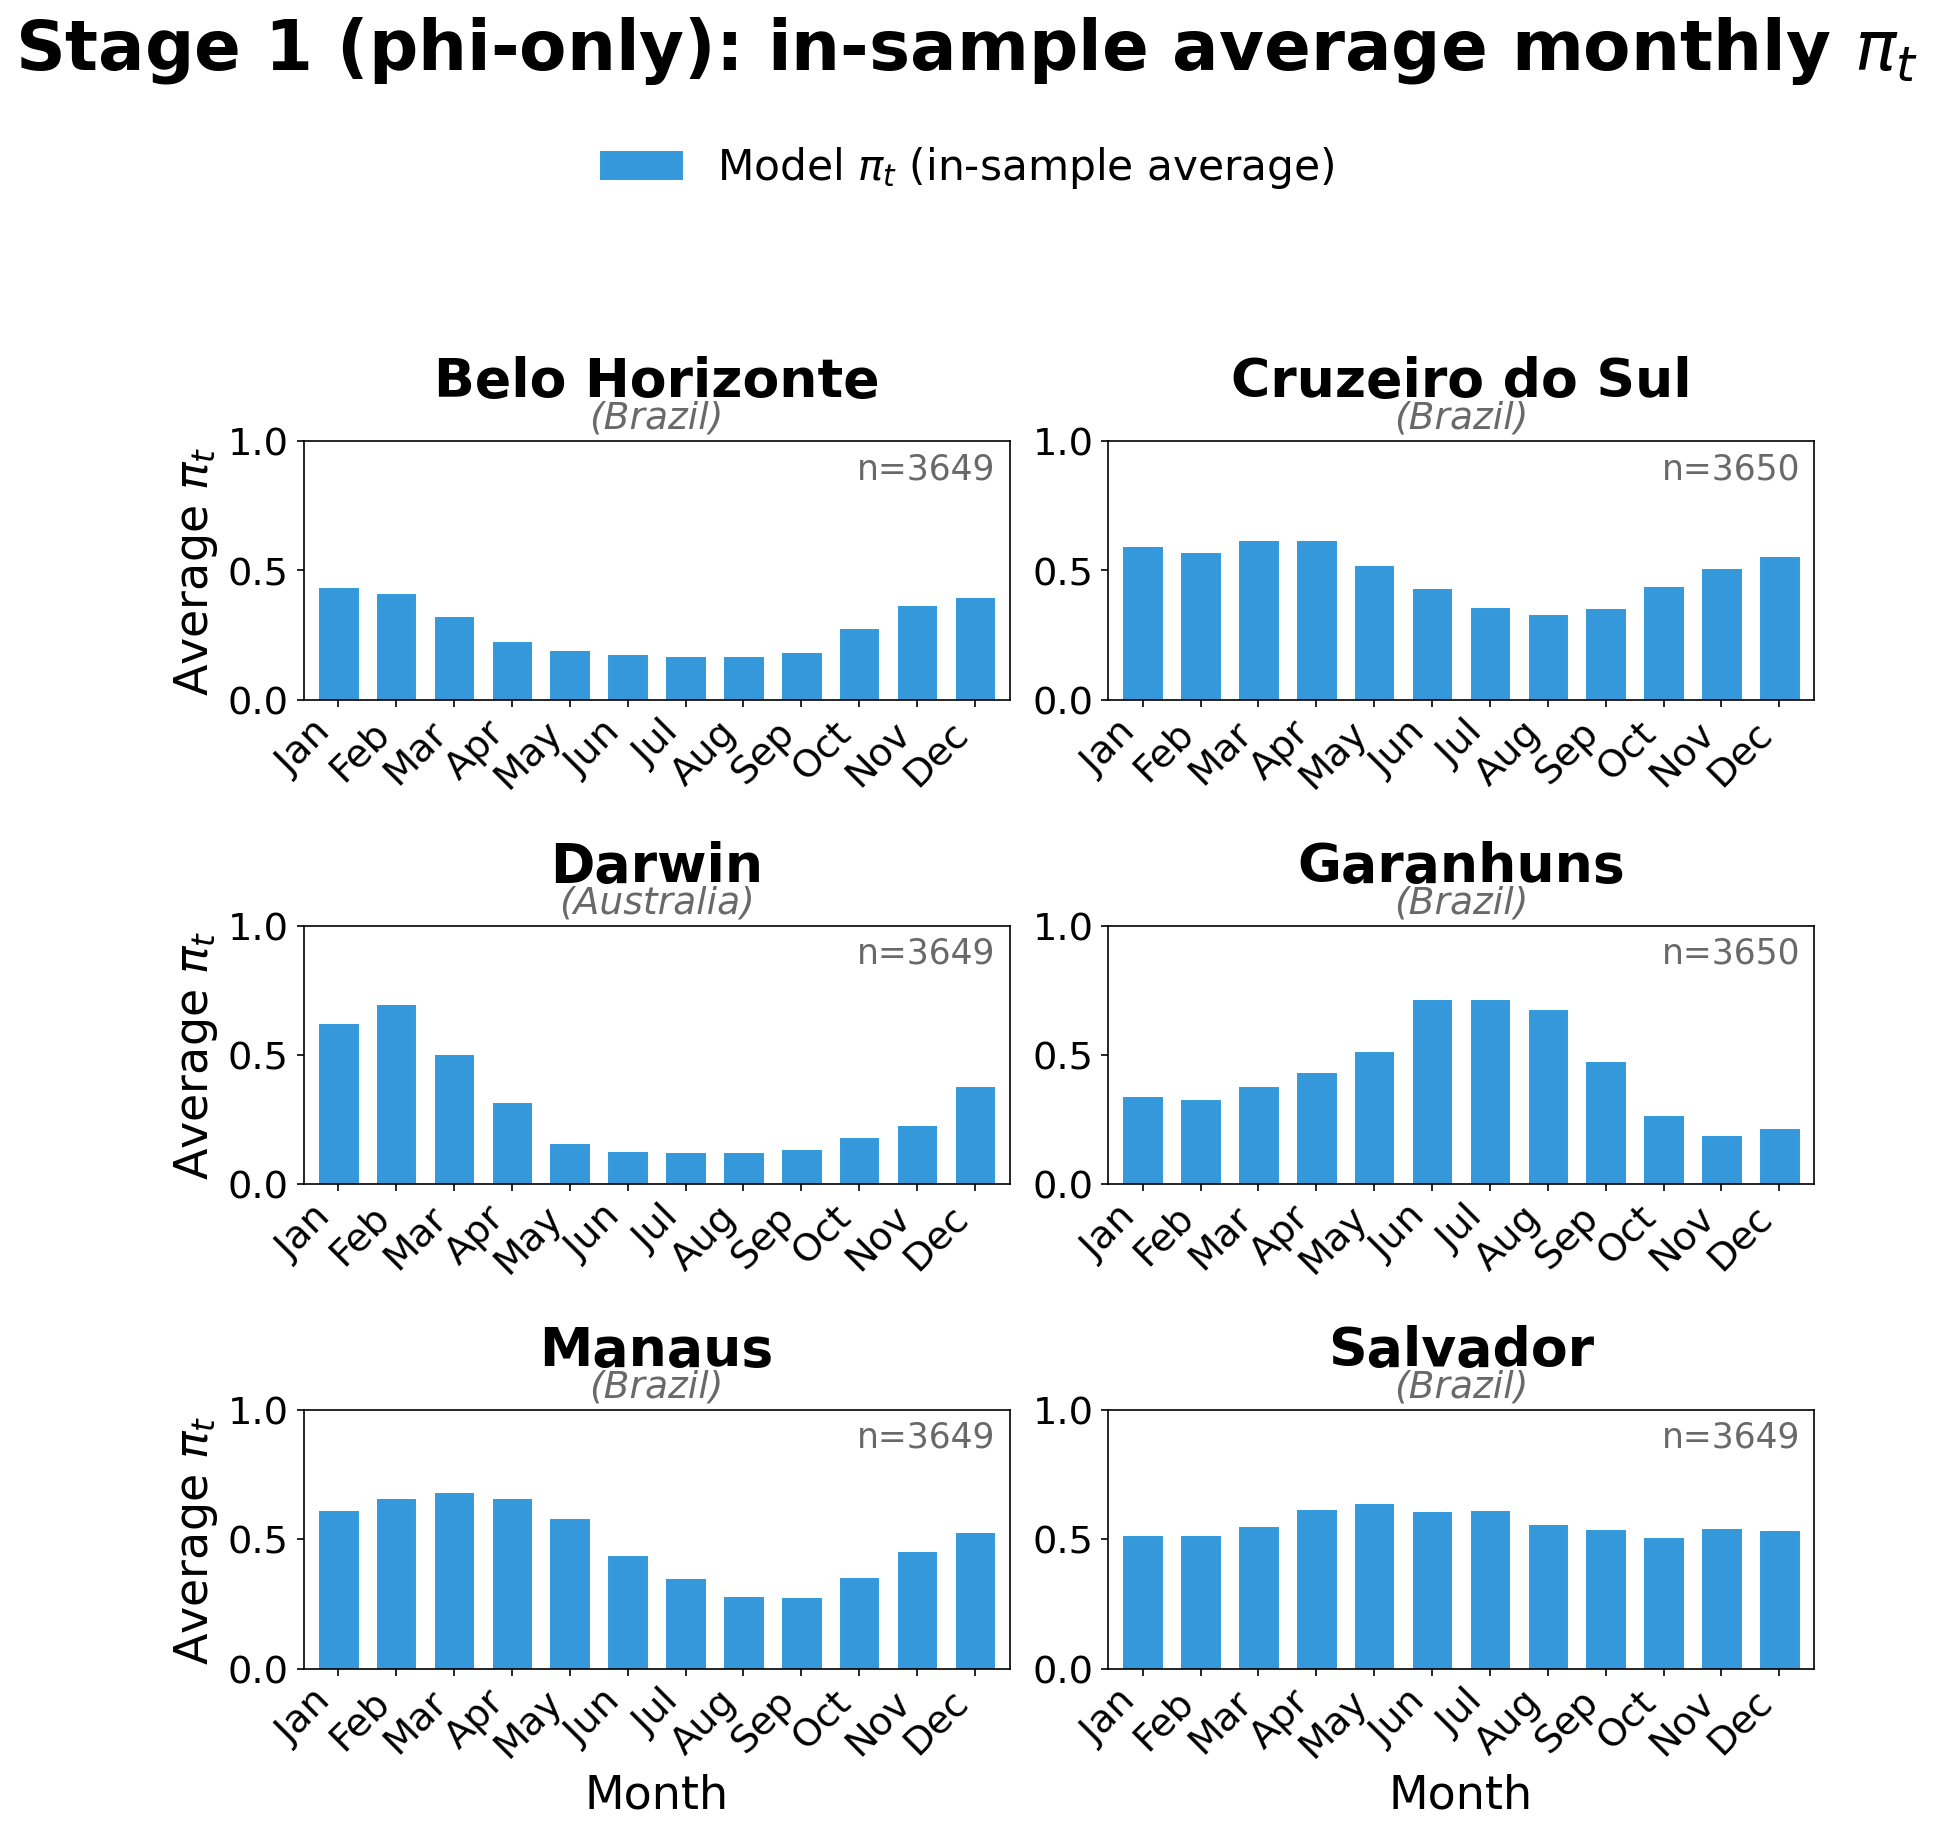

In [8]:
fig1 = monthly_pi_mosaic(
    pi_data, LOCATION_DISPLAY_NAMES,
    suptitle="Stage 1 (phi-only): in-sample average monthly $\\pi_t$",
    target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
    location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
)
path1 = save_mosaic(fig1, "stage1_phi_only_monthly_pi")

## Figure 2 -- $\pi_t$ vs. empirical wet-day fraction by calendar month

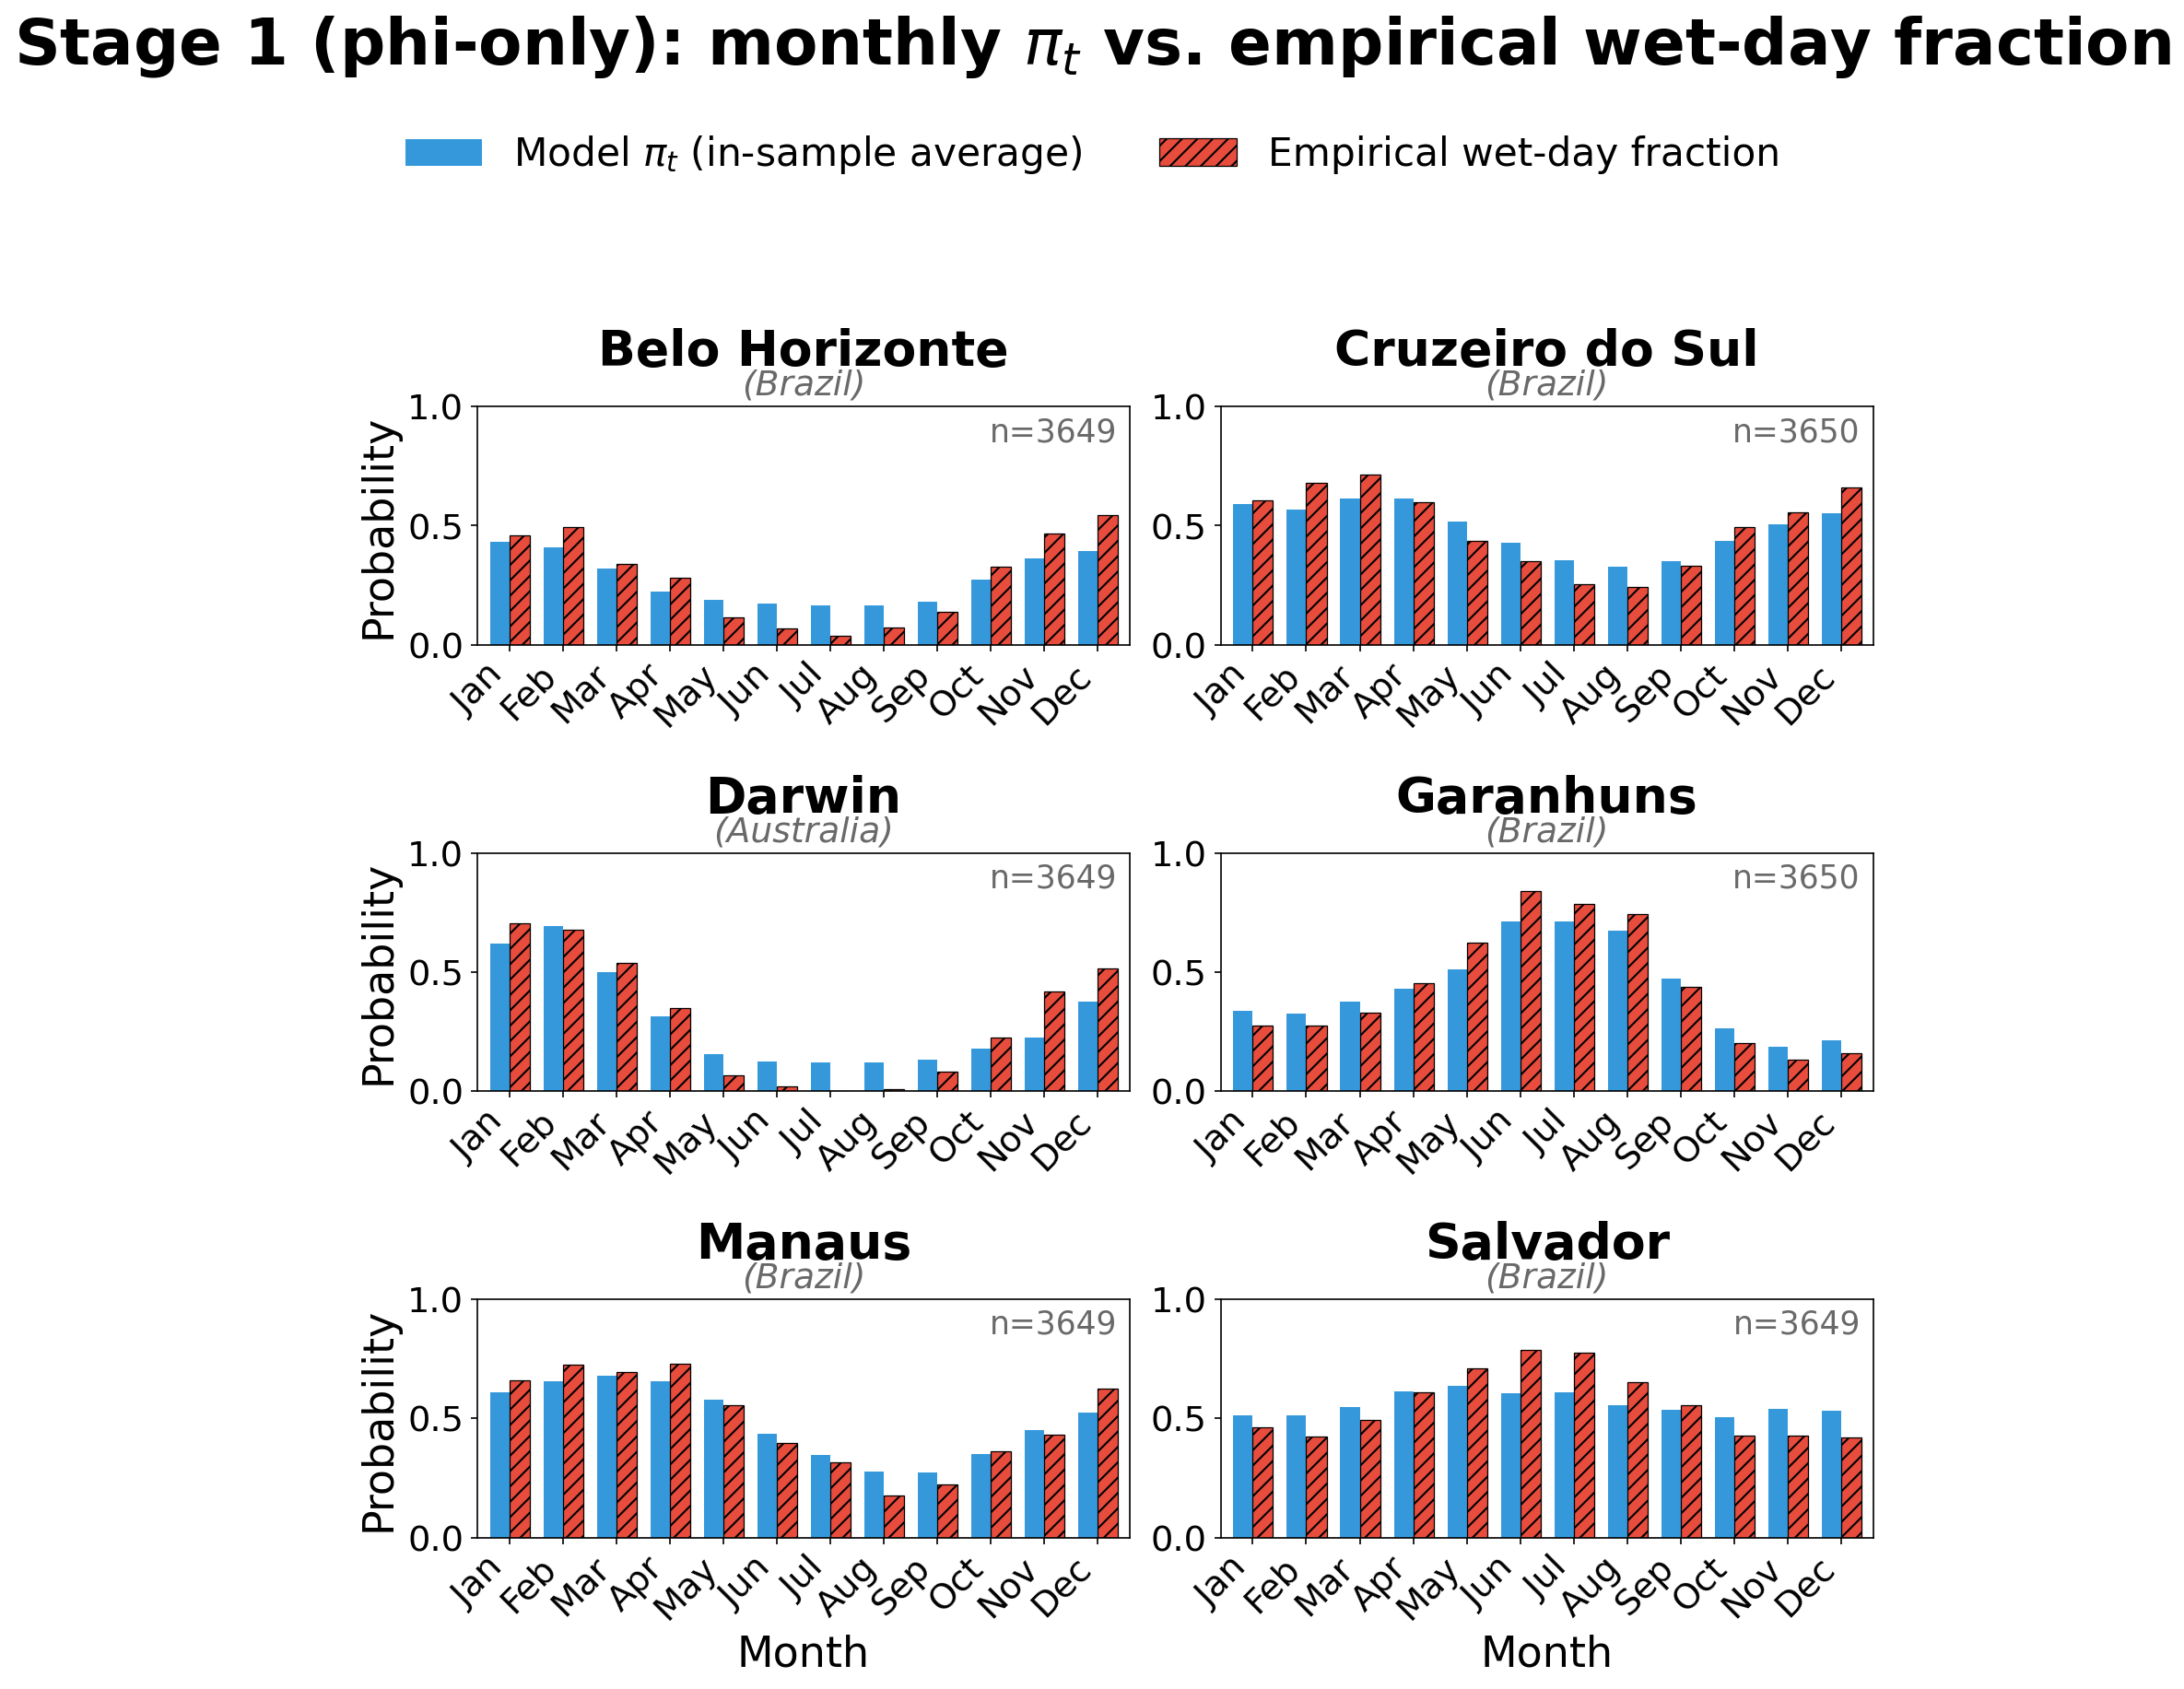

In [9]:
fig2 = monthly_pi_occurrence_mosaic(
    pi_data, LOCATION_DISPLAY_NAMES,
    suptitle="Stage 1 (phi-only): monthly $\\pi_t$ vs. empirical wet-day fraction",
    target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
    location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
)
path2 = save_mosaic(fig2, "stage1_phi_only_monthly_pi_vs_occurrence")

In [10]:
# =============================================================================
# Save a file index for the generated mosaics
# =============================================================================
index_df = pd.DataFrame({"file": [path1.name, path2.name]})
index_df.to_csv(TABLES_DIR / "mosaic_file_index.csv", index=False)
index_df


,file
0,stage1_phi_only_monthly_pi.png
1,stage1_phi_only_monthly_pi_vs_occurrence.png


## How to change the figure design

**Font size / readability in the PDF:** edit the "Figure design settings"
cell above (`TARGET_PRINT_WIDTH_IN`, `BASE_PRINT_PT`). That is the one
place this needs to change -- see that cell for why.

**Titles, axis labels, colors:** the two `suptitle=` strings are set
directly in the "Figure 1" / "Figure 2" cells above -- edit them there.
Per-panel titles are the location name plus a "(Country)" subtitle
(`LOCATION_NAMES` / `LOCATION_COUNTRIES`, built in the Configuration cell
from `data/station_loader.py`'s `mosaic_name()` and the `STATION_REGISTRY`
`"country"` field -- edit the registry there to rename a location or
change its country, not this notebook). Axis labels ("Average $\pi_t$",
"Probability", "Month") and bar colors (blue `#3498db` for the model's
$\pi_t$, red `#e74c3c` for the empirical wet-day fraction, per the user's
request) are set inside `diagnostics/plots.py`'s `_draw_monthly_pi_panel` /
`_draw_monthly_pi_occurrence_panel` -- both mosaic functions call these
same two drawers, so a color/label change there applies to both figures
at once, and cannot drift between them.

**Black-and-white printing:** Figure 2's empirical wet-day-fraction bars
also carry a diagonal `"///"` hatch on top of their red fill
(`_draw_monthly_pi_occurrence_panel`), so the two series stay visually
distinguishable by texture, not only by hue, if the dissertation is
printed or photocopied in black and white. To change the hatch pattern or
drop it, edit the single `ax.bar(..., hatch=...)` call for the empirical
series in that function.

**Which model is shown:** `diagnostics/pi_monthly.py`'s
`compute_monthly_pi_and_occurrence` always resolves the Stage 1 phi-only
winner (`resolve_stage_winner(winners, 1, "phi_only")`, reused from
`diagnostics/multilocation_mosaics.py`). To show a different stage/branch
instead, pass a different `(stage, branch)` pair to `resolve_stage_winner`
in that function -- but note the "one time-varying parameter" framing in
this notebook's introduction only holds for the phi-only branch.

To add a location: register it in `STATION_REGISTRY`
(`data/station_loader.py`) -- including its `"country"` and, if needed, a
`"mosaic_name"` override -- and add it to `LOCATIONS` in
`diagnostics/multilocation_mosaics.py` once its Stage 1 artifacts exist --
both mosaic functions already support any number of locations (the grid
grows to `ceil(n/2)` rows automatically), not just exactly 6.


## Output Index

- `reports/multi_location/pi_seasonality/stage1_phi_only_monthly_pi.png` /
  `.pdf` -- Figure 1 (average $\pi_t$ by month, one panel per location).
- `reports/multi_location/pi_seasonality/stage1_phi_only_monthly_pi_vs_occurrence.png`
  / `.pdf` -- Figure 2 ($\pi_t$ vs. empirical wet-day fraction by month).
- `reports/multi_location/pi_seasonality/tables/stage1_phi_only_winners.csv`
  -- which Stage 1 phi-only `model_id` was diagnosed at each location.
- `reports/multi_location/pi_seasonality/tables/monthly_pi_and_wet_fraction.csv`
  -- the exact numbers behind both figures, long format
  (location x month x avg_pi x empirical_wet_frac).
- `reports/multi_location/pi_seasonality/tables/mosaic_file_index.csv` --
  list of the two generated mosaic files.
